In [1]:
## Automatically create a gitignore file, based on the files that I want to keep


INCLUDE_PATHS = [
    "Meshes/",
    "Figures/",
    "README.md",
    "requirements.txt",
    "juptyer_notebooks/",
    "src/",
    "AirMatress_manuscript_rjmAF.docx",
    ".gitignore",  # optional: keep the ignore file itself
]

# Output file name
GITIGNORE_FILE = ".gitignore"


lines = ["# Automatically generated .gitignore\n", "/*\n"]

for path in INCLUDE_PATHS:
    # Ensure clean formatting
    clean_path = path.strip()
    if clean_path:
        lines.append(f"!{clean_path}\n")

with open(GITIGNORE_FILE, "w") as f:
    f.writelines(lines)

print(f"✅ Created {GITIGNORE_FILE} with {len(INCLUDE_PATHS)} included paths:")
for p in INCLUDE_PATHS:
    print(f"   • {p}")




✅ Created .gitignore with 8 included paths:
   • Meshes/
   • Figures/
   • README.md
   • requirements.txt
   • juptyer_notebooks/
   • src/
   • AirMatress_manuscript_rjmAF.docx
   • .gitignore


In [27]:
## This is the full pipeline for creating the dataframes for the analysis, and the idealised meshes

## Load in the data and create the confocal dataframe

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys

# Add parent directory to sys.path
parent_dir = str(Path.cwd().parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
import src.cross_section_helpers as csh

path_to_data = "../Meshes/"
confocal_results = "Onion meshes/pressure_pore/"
confocal_meshes = "Onion meshes/pressure_results/"
confocal_aniso_results = "Onion meshes anisotropy/pressure_pore/"
confocal_aniso_meshes = "Onion meshes anisotropy/pressure_results/"
selected_meshes = ['1_2', '1_3', '1_4', '1_5', '1_6', '1_8', '2_1', '2_3', '2_6a', '2_7', '3_2', '3_4', '3_6', '3_7']

## Get all files in the folder
confocal_results_files = [f for f in Path(path_to_data + confocal_results).glob("*.txt")]
confocal_mesh_files = [f for f in Path(path_to_data + confocal_meshes).glob("*.obj")]

## Keep only the selected meshes
confocal_results_files = [f for f in confocal_results_files if any(sel in str(f) for sel in selected_meshes)]
confocal_mesh_files = [f for f in confocal_mesh_files if any(sel in str(f) for sel in selected_meshes)]

confocal_aniso_results_files = [f for f in Path(path_to_data + confocal_aniso_results).glob("*.txt")]
confocal_aniso_mesh_files = [f for f in Path(path_to_data + confocal_aniso_meshes).glob("*.obj")]


In [17]:
## When creating the cross sections, we need to make sure that the area of the circles at the tips remains constant - this shouldn't be recalculated with each mesh.

## With that in mind, we should create entries for the midsection cross section for each mesh, and this shouldn't change.

## Define a function to visualise a cross section
from sklearn.decomposition import PCA

def show_cross_section(section_points):
    # Project 3D points to 2D using PCA
    pca = PCA(n_components=2)
    points_2d = pca.fit_transform(section_points)

    size_inches = [4,4]

    # Create figure with white background
    fig, ax = plt.subplots(1, 1, figsize=size_inches, facecolor='white')
    ax.set_facecolor('white')

    # Close the contour by adding the first point at the end
    closed_points = np.vstack([points_2d, points_2d[0]])

    # Plot the cross-section as a black line
    ax.plot(closed_points[:, 0], closed_points[:, 1], 'b-', linewidth=2)

    # Set equal aspect ratio and clean up axes
    ax.set_aspect('equal')

    # Remove axes ticks and labels for clean appearance
    ax.set_xticks([])
    ax.set_yticks([])

    # Tight layout to minimize white space
    plt.tight_layout()
    plt.show()

import trimesh

## Load all meshes in the folder
folder = "../Meshes/Onion_OBJ/"
obj_meshes = [f for f in Path(folder).glob("*.obj")]

def get_midsection_area(mesh):

    wall_vertices = csh.find_wall_vertices_vertex_normals(mesh, dot_thresh=0.2)
    centre_top, centre_bottom, top_wall_coords, bottom_wall_coords, top_wall_trace, bottom_wall_trace, centre_top_trace, centre_bottom_trace = csh.get_top_bottom_wall_centres(mesh, wall_vertices)
    midpoint, traces, section_points, local_axes = csh.get_midpoint_cross_section_from_centres(mesh, centre_top, centre_bottom)
    left_section, right_section, left_section_centre, right_section_centre, left_midsection_trace, right_midsection_trace, left_section_centre_trace, right_section_centre_trace = csh.get_left_right_midsections(section_points, midpoint, local_axes)

    ## The radius of the circles to place at the top and bottom walls is taken from the radius of the midsections
    area1 = csh.cross_section_area_2d(left_section)
    area2 = csh.cross_section_area_2d(right_section)

    avg_area = 0.5 * (area1 + area2)
    #show_cross_section(left_section)

    return area1, area2

areas = []

for file in obj_meshes:
    mesh = trimesh.load_mesh(file)
    midsection_area1, midsection_area2 = get_midsection_area(mesh)
    print(f"Midsection area for {file}: {midsection_area1}")
    areas.append((midsection_area1, midsection_area2))
## Save the areas to a dataframe
areas_df = pd.DataFrame(areas, columns=['midsection_area1', 'midsection_area2'])
areas_df['mesh_file'] = [str(f.name) for f in obj_meshes]
areas_df.to_csv("midsection_areas.csv", index=False)

areas_df

Midsection area for ../Meshes/Onion_OBJ/Ac_DA_1_8.obj: 132.57874164250578
Midsection area for ../Meshes/Onion_OBJ/Ac_DA_2_6a.obj: 143.2663334015558
Midsection area for ../Meshes/Onion_OBJ/Ac_DA_2_6b.obj: 141.14561511858483
Midsection area for ../Meshes/Onion_OBJ/Ac_DA_2_3.obj: 110.07825821851341
Midsection area for ../Meshes/Onion_OBJ/Ac_DA_2_1.obj: 104.4614079694904
Midsection area for ../Meshes/Onion_OBJ/Ac_DA_2_4.obj: 148.29526463618026
Midsection area for ../Meshes/Onion_OBJ/Ac_DA_2_7.obj: 111.13062120936084
Midsection area for ../Meshes/Onion_OBJ/Ac_DA_3_1.obj: 129.27091242655982
Midsection area for ../Meshes/Onion_OBJ/Ac_DA_1_3.obj: 133.36738365685974
Midsection area for ../Meshes/Onion_OBJ/Ac_DA_1_2.obj: 123.40573150567293
Midsection area for ../Meshes/Onion_OBJ/Ac_DA_3_2.obj: 174.2948327739316
Midsection area for ../Meshes/Onion_OBJ/Ac_DA_3_3.obj: 176.50113593597564
Midsection area for ../Meshes/Onion_OBJ/Ac_DA_3_7.obj: 186.14272023472174
Midsection area for ../Meshes/Onion_OBJ

,midsection_area1,midsection_area2,mesh_file
0,132.578742,149.888908,Ac_DA_1_8.obj
1,143.266333,146.215870,Ac_DA_2_6a.obj
2,141.145615,154.681310,Ac_DA_2_6b.obj
3,110.078258,132.631805,Ac_DA_2_3.obj
4,104.461408,105.101363,Ac_DA_2_1.obj
5,148.295265,141.210011,Ac_DA_2_4.obj
6,111.130621,106.135754,Ac_DA_2_7.obj
7,129.270912,126.251476,Ac_DA_3_1.obj
8,133.367384,126.652304,Ac_DA_1_3.obj
9,123.405732,139.226647,Ac_DA_1_2.obj


In [11]:
import importlib
import mesh_functions
importlib.reload(mesh_functions)
from mesh_functions import process_mesh
from concurrent.futures import ThreadPoolExecutor, as_completed

# Parallel processing for the confocal meshes - takes ~ 7 min to run
## We need to pass in the correct midsection areas for each mesh
midsection_areas = pd.read_csv("midsection_areas.csv")
mid_area_dict = {}
for index, row in midsection_areas.iterrows():
    mesh_id = "_".join(row['mesh_file'].split("_")[2:4])
    mid_area_dict[mesh_id] = (row['midsection_area1'], row['midsection_area2'])


confocal_results = []
with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_mesh, file, confocal_results_files, confocal_mesh_files, mid_area_left_0=mid_area_dict[mesh_id][0], mid_area_right_0=mid_area_dict[mesh_id][1]) for file in confocal_mesh_files]
    for future in as_completed(futures):
        confocal_results.append(future.result())

df = pd.DataFrame(confocal_results)
df.sort_values(by=["Mesh ID"], inplace=True)
display(df)

df.to_csv("confocal_results_df_batch.csv", index=False)

,Mesh ID,Cross-section type,Pressure,Midsection AR left,Midsection AR right,Midsection Points Left,Midsection Points Right,Tip AR left,Tip AR right,Tip Points Left,Tip Points Right,Major length left,Major length right,Minor length left,Minor length right,Pore Area,Volume,Spline length
294,1_2,confocal,1.8,0.991440,1.058056,"[[-9.5206135036293, 1.9712913064449447, -7.781...","[[13.637118355538, -0.13826959212610634, -7.59...",1.017839,1.073113,"[[-1.3312037749272618, -8.800379351662778, -6....","[[8.785915656768076, 19.23977010893529, -3.472...",14.703756,16.196841,14.830710,15.308120,62.66,15031.584436,78.347546
138,1_2,confocal,0.2,1.141272,1.168432,"[[-3.264001223371808, 0.2042598711030964, -3.9...","[[14.374400094202956, 0.2921925529384113, 6.23...",1.019604,1.126592,"[[0.9460600614193383, -6.416843454929969, -1.7...","[[9.04191638987568, 19.498564772259172, 4.0414...",14.460975,15.359668,12.670928,13.145539,54.11,12193.199293,75.825877
140,1_2,confocal,2.0,0.996552,1.057070,"[[-17.251775002259016, 1.7435709421405805, 1.3...","[[6.382120668023636, -0.7973730013832596, 4.78...",1.013777,1.069982,"[[-7.142400578803228, -18.76924780392428, 0.38...","[[2.526719065547148, 6.498020370808973, 2.7011...",14.901941,16.364588,14.953503,15.481086,62.92,15380.832371,78.381456
72,1_2,confocal,1.1,1.007034,1.073585,"[[-2.3423897934783957, 0.015638084840519983, -...","[[20.034584189554685, 0.894925215177889, 2.674...",0.978731,1.092295,"[[0.9123765011881105, -6.5272527384160535, -1....","[[6.773783116557068, 15.515737769758228, -5.54...",14.275617,15.694456,14.175904,14.618737,61.25,13834.452885,77.601288
37,1_2,confocal,1.7,0.996863,1.065623,"[[-10.211835382524344, 1.9793372042403168, -7....","[[20.144652223473443, -1.1480901318901884, -3....",1.018929,1.075346,"[[-6.648317824812505, -18.010238400796613, 2.5...","[[6.31808476073307, 14.258182180436634, 9.4993...",14.673092,16.170037,14.719267,15.174261,62.55,14858.501864,78.416684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40,3_7,confocal,0.5,0.960178,1.011307,"[[-1.9353607730857703, -6.384733616243036, 6.0...","[[4.695050205474107, 14.279962021320049, -4.50...",1.037777,0.999771,"[[5.525012155242252, -1.7106186772047562, -0.6...","[[-13.946864710971147, 15.070930054175207, 2.3...",15.992079,15.308389,16.655325,15.137237,26.22,13093.400891,69.792167
41,3_7,confocal,0.4,0.958373,1.010186,"[[-5.806083452419303, -13.075680084423963, -7....","[[0.7168204436173955, 4.059954751048946, -3.09...",1.042711,1.034792,"[[5.522771015068833, -1.7117183036036956, -0.6...","[[-4.679028487323461, 2.881615849889917, -0.14...",15.882546,15.200810,16.572406,15.047538,26.30,12919.897549,69.575149
87,3_7,confocal,1.1,0.973128,1.015255,"[[-4.0140606199910165, -11.712850892164626, 5....","[[6.1107186930466835, 17.074766742841856, 0.50...",1.029779,0.953077,"[[5.489803426731538, -1.6331031607995437, -1.2...","[[-7.18672386847728, 7.372454954904783, -5.000...",16.677811,15.910504,17.138353,15.671433,25.51,14120.262127,70.396274
149,3_7,confocal,1.9,0.987698,1.019182,"[[-4.418558212149423, -8.478040388889335, -10....","[[0.4787279196271489, 3.6553197774439057, -2.7...",1.015784,1.024199,"[[5.401105083924707, -1.6187515253634879, -1.0...","[[-4.924493460845401, 3.6102496869446665, -1.1...",17.557627,16.649195,17.776315,16.335840,23.99,15542.477761,71.350871


In [12]:
## Create the dataframe for the confocal results files with anisotropy

midsection_areas = pd.read_csv("midsection_areas.csv")
mid_area_dict = {}
for index, row in midsection_areas.iterrows():
    mesh_id = "_".join(row['mesh_file'].split("_")[2:4])
    mid_area_dict[mesh_id] = (row['midsection_area1'], row['midsection_area2'])


confocal_aniso_results = []
with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_mesh, file, confocal_aniso_results_files, confocal_aniso_mesh_files, mid_area_left_0=mid_area_dict[mesh_id][0], mid_area_right_0=mid_area_dict[mesh_id][1]) for file in confocal_mesh_files]
    for future in as_completed(futures):
        confocal_results.append(future.result())

df = pd.DataFrame(confocal_aniso_results)
df.sort_values(by=["Mesh ID"], inplace=True)
display(df)

df.to_csv("confocal_aniso_results_df_batch.csv", index=False)

KeyError: 'Mesh ID'

In [19]:
from pathlib import Path
import sys
import pandas as pd

# Add parent directory to sys.path
parent_dir = str(Path.cwd().parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

import idealised_mesh_functions as imf
import importlib
import trimesh
importlib.reload(imf)

df = pd.read_csv("confocal_results_df_batch.csv")
df_mesh = df[df["Mesh ID"] == "2_7"].copy()

mesh_id="2_7"

mesh = trimesh.load(f"../Meshes/Onion_OBJ/Ac_DA_{mesh_id}.obj", force='mesh')
length_major, length_minor = imf.get_major_minor_stomata(mesh)

# Update all rows for this mesh_id (or just pressure==0.0 if you prefer)
df_mesh.loc[df_mesh["Mesh ID"] == mesh_id, "Measured major length"] = length_major
df_mesh.loc[df_mesh["Mesh ID"] == mesh_id, "Measured minor length"] = length_minor

imf.run_idealised_mesh_creation(["2_7"], df_mesh, major_segments=300, minor_segments=100, ar = "circular")

Processing mesh: 2_7
Target pore area: 49.29
Target midsection aspect ratio: 1.3404643076382317
Target length: 41.64640154334147
Target width: 33.87665820334844
Initial minor radii: a=6.8812, b=6.8812
Initial major radii: a=10.0572, b=13.9420

Attempt 1:
Exported scene for inspection: idealised_attempt_2_7_1.obj
Central pore area: 67.00
Difference from target pore area: -17.71
Adjusting minor radii by -0.2473 to a=7.1284, b=7.1284
New major radii: a=9.8099, b=13.6948

Attempt 2:
Exported scene for inspection: idealised_attempt_2_7_2.obj
Central pore area: 51.68
Difference from target pore area: -2.39
Adjusting minor radii by -0.0346 to a=7.1631, b=7.1631
New major radii: a=9.7753, b=13.6601

Attempt 3:
Exported scene for inspection: idealised_attempt_2_7_3.obj
Central pore area: 49.65
Difference from target pore area: -0.36
Pore area within acceptable range. Stopping iterations.
Final mesh saved as: idealised_final_2_7_circular.obj
Completed processing mesh 2_7


In [20]:
merged_mesh = trimesh.load(f'idealised_final_{mesh_id}_circular.obj', force='mesh')
merged_mesh.show()
merged_mesh.export(f'idealised_final_merged{mesh_id}_circular.obj')

'# https://github.com/mikedh/trimesh\n\no right\nv 0.00000000 6.49706022 0.00000000\nv 0.00000000 6.51119490 0.44977290\nv 0.00000000 6.55354317 0.89777076\nv 0.00000000 6.62393789 1.34222552\nv 0.00000000 6.72210124 1.78138314\nv 0.00000000 6.84764583 2.21351045\nv 0.00000000 7.00007619 2.63690204\nv 0.00000000 7.17879073 3.04988699\nv 0.00000000 7.38308416 3.45083542\nv 0.00000000 7.61215023 3.83816499\nv 0.00000000 7.86508491 4.21034707\nv 0.00000000 8.14088999 4.56591283\nv 0.00000000 8.43847699 4.90345903\nv 0.00000000 8.75667147 5.22165351\nv 0.00000000 9.09421766 5.51924051\nv 0.00000000 9.44978343 5.79504558\nv 0.00000000 9.82196551 6.04798027\nv 0.00000000 10.20929507 6.27704633\nv 0.00000000 10.61024351 6.48133976\nv 0.00000000 11.02322845 6.66005431\nv 0.00000000 11.44662005 6.81248466\nv 0.00000000 11.87874736 6.93802925\nv 0.00000000 12.31790497 7.03619261\nv 0.00000000 12.76235974 7.10658733\nv 0.00000000 13.21035759 7.14893559\nv 0.00000000 13.66013050 7.16307028\nv 0.00

In [21]:
import idealised_mesh_functions as imf
import trimesh

## Add in major and minor lengths
for mesh_id in selected_meshes:
    mesh = trimesh.load(f"../Meshes/Onion_OBJ/Ac_DA_{mesh_id}.obj", force='mesh')
    length_major, length_minor = imf.get_major_minor_stomata(mesh)
    
    # Update all rows for this mesh_id (or just pressure==0.0 if you prefer)
    df.loc[df["Mesh ID"] == mesh_id, "Measured major length"] = length_major
    df.loc[df["Mesh ID"] == mesh_id, "Measured minor length"] = length_minor

print(df[["Mesh ID", "Measured major length", "Measured minor length"]].head())
display(df.head(5))

  Mesh ID  Measured major length  Measured minor length
0     1_2              42.674713              38.841329
1     1_2              42.674713              38.841329
2     1_2              42.674713              38.841329
3     1_2              42.674713              38.841329
4     1_2              42.674713              38.841329


,Mesh ID,Cross-section type,Pressure,Midsection AR left,Midsection AR right,Midsection Points Left,Midsection Points Right,Tip AR left,Tip AR right,Tip Points Left,Tip Points Right,Major length left,Major length right,Minor length left,Minor length right,Pore Area,Volume,Spline length,Measured major length,Measured minor length
0,1_2,confocal,1.8,0.991440,1.058056,[[ -9.5206135 1.97129131 -7.78168744]\n [ ...,[[ 1.36371184e+01 -1.38269592e-01 -7.59985723e...,1.017839,1.073113,[[ -1.33120377 -8.80037935 -6.45036384]\n [ ...,[[ 8.78591566e+00 1.92397701e+01 -3.47246517e...,14.703756,16.196841,14.830710,15.308120,62.66,15031.584436,78.347546,42.674713,38.841329
1,1_2,confocal,0.2,1.141272,1.168432,[[-3.26400122e+00 2.04259871e-01 -3.99673108e...,[[ 1.43744001e+01 2.92192553e-01 6.23080816e...,1.019604,1.126592,[[ 9.46060061e-01 -6.41684345e+00 -1.74546752e...,[[ 9.04191639 19.49856477 4.04141364]\n [ 9.0...,14.460975,15.359668,12.670928,13.145539,54.11,12193.199293,75.825877,42.674713,38.841329
2,1_2,confocal,2.0,0.996552,1.057070,[[-17.251775 1.74357094 1.35298664]\n [-...,[[ 6.38212067e+00 -7.97373001e-01 4.78044010e...,1.013777,1.069982,[[ -7.14240058 -18.7692478 0.38664161]\n [ ...,[[ 2.52671907 6.49802037 2.70117356]\n [ 2.5...,14.901941,16.364588,14.953503,15.481086,62.92,15380.832371,78.381456,42.674713,38.841329
3,1_2,confocal,1.1,1.007034,1.073585,[[-2.34238979e+00 1.56380848e-02 -1.83247800e...,[[ 2.00345842e+01 8.94925215e-01 2.67427912e...,0.978731,1.092295,[[ 0.9123765 -6.52725274 -1.71752303]\n [ ...,[[ 6.77378312e+00 1.55157378e+01 -5.54634331e...,14.275617,15.694456,14.175904,14.618737,61.25,13834.452885,77.601288,42.674713,38.841329
4,1_2,confocal,1.7,0.996863,1.065623,[[-10.21183538 1.9793372 -7.77069463]\n [-...,[[ 2.01446522e+01 -1.14809013e+00 -3.73548778e...,1.018929,1.075346,[[-6.64831782e+00 -1.80102384e+01 2.57071257e...,[[ 6.31808476e+00 1.42581822e+01 9.49936661e...,14.673092,16.170037,14.719267,15.174261,62.55,14858.501864,78.416684,42.674713,38.841329


In [53]:
df_aniso = pd.read_csv("confocal_aniso_results_df_batch.csv")
## Add in major and minor lengths
for mesh_id in selected_meshes:
    mesh = trimesh.load(f"../Meshes/Onion_OBJ/Ac_DA_{mesh_id}.obj", force='mesh')
    length_major, length_minor = imf.get_major_minor_stomata(mesh)
    
    # Update all rows for this mesh_id (or just pressure==0.0 if you prefer)
    df_aniso.loc[df["Mesh ID"] == mesh_id, "Measured major length"] = length_major
    df_aniso.loc[df["Mesh ID"] == mesh_id, "Measured minor length"] = length_minor

print(df_aniso[["Mesh ID", "Measured major length", "Measured minor length"]].head())
display(df_aniso.head(5))
df_aniso.to_csv("confocal_aniso_results_df_batch.csv", index=False)

  Mesh ID  Measured major length  Measured minor length
0     1_2              41.646402              33.876658
1     1_2              42.617543              36.368758
2     1_2              40.359912              35.065321
3     1_2              40.359912              35.065321
4     1_2              42.674713              38.841329


,Mesh ID,Cross-section type,Pressure,Midsection AR left,Midsection AR right,Midsection Points Left,Midsection Points Right,Tip AR left,Tip AR right,Tip Points Left,Tip Points Right,Major length left,Major length right,Minor length left,Minor length right,Pore Area,Volume,Spline length,Measured major length,Measured minor length
0,1_2,confocal,1.7,1.064597,1.132872,[[-1.39571192e+01 1.39631652e+00 -7.18601369e...,[[ 1.61638522e+01 -2.35854505e+00 4.29410228e...,1.034708,1.097855,[[-1.74080446e+00 -7.49874979e+00 -3.60372034e...,[[ 6.71487794 17.75833442 -4.43124197]\n [ 6.7...,13.924607,15.235940,13.079694,13.448953,77.52,12537.074570,79.590379,41.646402,33.876658
1,1_2,confocal,1.1,1.078403,1.127642,[[-18.86720277 -1.3773458 -2.73288267]\n [-...,[[ 6.63040369e+00 -5.54877148e-01 4.93754625e...,0.979603,1.113673,[[ -0.84137131 -7.31491487 -2.15836242]\n [ ...,[[ 1.00355309 6.68658881 -1.38735848]\n [ 1.0...,13.942591,15.102675,12.928928,13.393146,70.74,12204.616491,78.692444,42.617543,36.368758
2,1_2,confocal,1.0,1.083790,1.164316,[[-1.65862082e+01 5.85954499e-01 3.37915437e...,[[ 4.03201325 -0.60390631 -2.90162213]\n [ 4.1...,1.043873,1.113909,[[-1.90463647e+00 -7.69631965e+00 -4.17678047e...,[[ 1.25951737 7.14720468 3.96579737]\n [ 1.2...,13.966365,15.331330,12.886595,13.167669,69.42,12146.047305,78.338247,40.359912,35.065321
3,1_2,confocal,0.9,1.084335,1.140472,[[-1.62099107e+01 -8.10328197e-01 -6.18727994e...,[[ 1.84140766e+01 8.27481203e-01 -2.66317083e...,0.985616,1.113501,[[ -0.83560379 -7.25927275 -2.17290012]\n [ ...,[[ 1.25183996 7.27577948 4.14423929]\n [ 1.2...,13.958531,15.173240,12.872898,13.304351,68.08,12085.903059,78.119167,40.359912,35.065321
4,1_2,confocal,1.2,1.075023,1.150300,[[-1.80991439e+01 9.15802814e-01 1.62165429e...,[[17.99423617 -1.67959376 -4.0142999 ]\n [17.8...,1.037165,1.107814,[[ -3.56096093 -10.81041866 4.26569072]\n [ ...,[[ 4.1548944 13.00858854 -5.67686766]\n [ 4.0...,13.931664,15.274248,12.959413,13.278495,71.92,12261.706365,78.689589,42.674713,38.841329


In [ ]:
## Create the idealised meshes, using the data in the dataframe.
## If the meshes are too coarse, the simulations won't converge: currently trying 300, 100.
## 21 minutes to run

from pathlib import Path
import sys
## Code to create the idealised meshes
# Add parent directory to sys.path
parent_dir = str(Path.cwd().parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)


imf.run_idealised_mesh_creation(selected_meshes, df, major_segments=300, minor_segments=100, ar = "oval")
imf.run_idealised_mesh_creation(selected_meshes, df, major_segments=300, minor_segments=100, ar = "circular")


Processing mesh: 1_2
Target pore area: 40.92
Target midsection aspect ratio: 1.5472944059232705
Target length: 42.67471343341737
Target width: 38.841328678137174
Initial minor radii: a=8.0882, b=5.2273
Initial major radii: a=11.3325, b=13.2492

Attempt 1:
Exported scene for inspection: idealised_attempt_1_2_1.obj
Central pore area: 51.61
Difference from target pore area: -10.69
Adjusting minor radii by -0.2113 to a=8.2994, b=5.4386
New major radii: a=11.1212, b=13.0379

Attempt 2:
Exported scene for inspection: idealised_attempt_1_2_2.obj
Central pore area: 40.98
Difference from target pore area: -0.06
Pore area within acceptable range. Stopping iterations.
Final mesh saved as: idealised_final_1_2_oval.obj
Completed processing mesh 1_2
Processing mesh: 1_3
Target pore area: 44.65
Target midsection aspect ratio: 1.4524772174794591
Target length: 41.31916278837674
Target width: 38.24586474713641
Initial minor radii: a=7.9248, b=5.4561
Initial major radii: a=11.1981, b=12.7348

Attempt 1:

In [23]:
## We need to create our MDX friendly versions of the idealised meshes

for mesh_id in selected_meshes:
    merged_mesh = trimesh.load(f'idealised_final_{mesh_id}_oval.obj', force='mesh')
    merged_mesh.show()
    merged_mesh.export(f'idealised_final_mdx_{mesh_id}_oval.obj')
    
    merged_mesh_circular = trimesh.load(f'idealised_final_{mesh_id}_circular.obj', force='mesh')
    merged_mesh_circular.show()
    merged_mesh_circular.export(f'idealised_final_mdx_{mesh_id}_circular.obj')

In [4]:
## Analyse the simulations results
## Create the dataframe with the idealised data
idealised_results = "Idealised/pressure_pore/"
idealised_meshes = "Idealised/pressure_results/"

## Load in the data for the idealised meshes
idealised_results_files = [f for f in Path(path_to_data + idealised_results).glob("*.txt")]
idealised_mesh_files = [f for f in Path(path_to_data + idealised_meshes).glob("*.obj")]

## Keep only the selected meshes
idealised_results_files = [f for f in idealised_results_files if any(sel in str(f) for sel in selected_meshes)]
idealised_mesh_files = [f for f in idealised_mesh_files if any(sel in str(f) for sel in selected_meshes)]

In [5]:
## Create the idealised results dataframe

import concurrent.futures
import pandas as pd
import cross_section_helpers as csh
import mesh_functions
import importlib
importlib.reload(mesh_functions)
from mesh_functions import process_idealised_mesh

rows = []
with concurrent.futures.ThreadPoolExecutor() as executor:
    for result in executor.map(process_idealised_mesh, idealised_mesh_files):
        rows.append(result)

df = pd.DataFrame(rows)
df.sort_values(by=["Mesh ID", "Cross-section type"], inplace=True)
df.to_csv("idealised_results_df.csv", index=False)

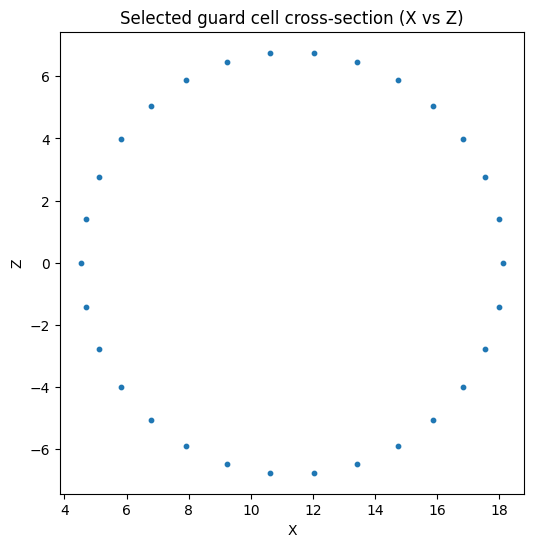

{'Mesh ID': '2_1',
 'Cross-section type': 'circular',
 'Pressure (MPa)': 0.0,
 'Aspect Ratio': [np.float64(0.9945195765233638)],
 'Pore Area (um^2)': np.float64(73.43730000000001)}

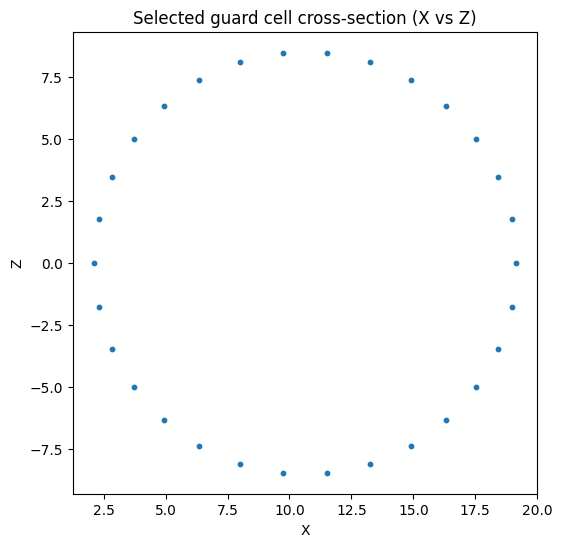

{'Mesh ID': '3_6',
 'Cross-section type': 'circular',
 'Pressure (MPa)': 0.0,
 'Aspect Ratio': [np.float64(1.0055092079695038)],
 'Pore Area (um^2)': np.float64(37.5148)}

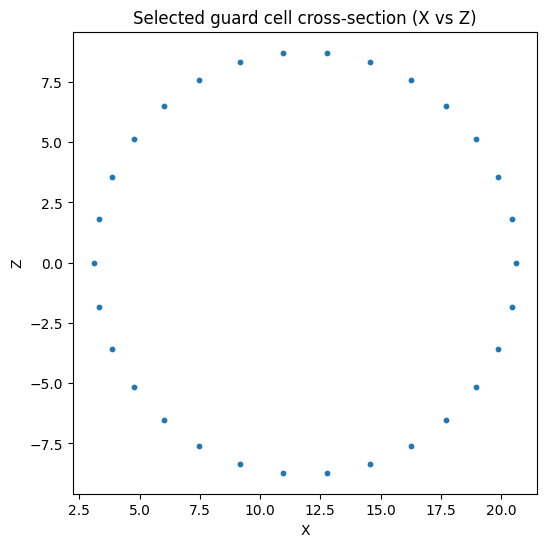

{'Mesh ID': '1_5',
 'Cross-section type': 'circular',
 'Pressure (MPa)': 0.0,
 'Aspect Ratio': [np.float64(1.0055089986273242)],
 'Pore Area (um^2)': np.float64(49.4647)}

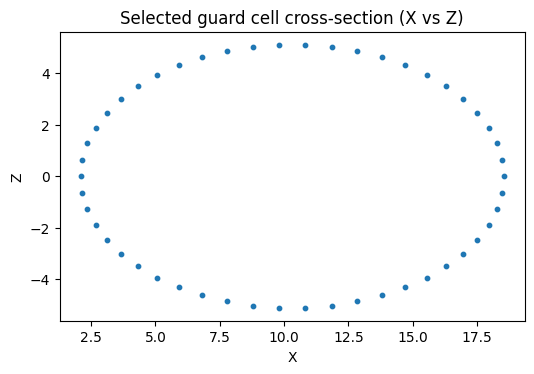

{'Mesh ID': '2_6a',
 'Cross-section type': 'oval',
 'Pressure (MPa)': 0.0,
 'Aspect Ratio': [np.float64(1.6087443814505646)],
 'Pore Area (um^2)': np.float64(21.0004)}

In [30]:
import mesh_functions
import importlib
importlib.reload(mesh_functions)
from mesh_functions import process_idealised_mesh

for i in range(100):
    if "0.0" in idealised_mesh_files[i].stem:
        output = process_idealised_mesh(idealised_mesh_files[i])
        display(output)